# A3 - Tema: Algoritmi Evolutivi si Swarm Intelligence

**Continut:**
1. Algoritm Evolutiv pentru **codificare reala** (Functia Griewank - problema 8)
2. PSO (Particle Swarm Optimization) pentru codificare reala (Functia Griewank)
3. Algoritm Evolutiv pentru **rucsac** (codificare binara) - din laborator
4. Algoritm Evolutiv pentru **TSP** (codificare prin permutari) - din laborator
5. Tabele de rezultate cu minim 5 configuratii de parametri
6. Vizualizari ale evolutiei fitness-ului
7. Analiza si comparatie cu algoritmii anteriori (RHC, SAHC, SA, TS)


## 0. Imports si utilitare comune

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time
import copy
from typing import List, Tuple, Callable

np.random.seed(42)
random.seed(42)


---
## 1. Problema de codificare reala: Functia Griewank (problema 8)

**Formula:**
$$f(x) = \sum_{i=1}^{d} \frac{x_i^2}{4000} - \prod_{i=1}^{d} \cos\left(\frac{x_i}{\sqrt{i}}\right) + 1$$

**Domeniu:** $x_i \in [-600, 600]$, pentru $i = 1, ..., d$

**Optim global:** $f(x^*) = 0$, la $x^* = (0, 0, ..., 0)$

**Caracteristici:** Functie multimodala cu optime locale distribuite regulat. 
Similar cu functia Rastrigin - are multi optimi locali dar distributi simetric.


In [2]:
# ── Functia Griewank ─────────────────────────────────────────────────────────

LOWER_BOUND = -600.0
UPPER_BOUND =  600.0

def griewank(x: np.ndarray) -> float:
    """
    Calculeaza valoarea functiei Griewank.
    
    Formula:
        f(x) = sum(x_i^2 / 4000) - prod(cos(x_i / sqrt(i))) + 1
    
    INPUT
    -----
    x : np.ndarray - vectorul solutie de dimensiune d
    
    OUTPUT
    ------
    float - valoarea functiei (optim global = 0 la x=(0,...,0))
    """
    d = len(x)
    soma  = np.sum(x**2) / 4000.0
    prod  = np.prod(np.cos(x / np.sqrt(np.arange(1, d + 1))))
    return soma - prod + 1.0

# Test rapid
print("f([0,0,0]) =", griewank(np.array([0.0, 0.0, 0.0])))   # trebuie 0
print("f([1,1,1]) =", griewank(np.array([1.0, 1.0, 1.0])))


f([0,0,0]) = 0.0
f([1,1,1]) = 0.656567738230001


---
## 2. Algoritm Evolutiv pentru codificare reala

### Componente:
- **Populatie:** vectori reali in [-600, 600]^d
- **Selectie parinti:** turneu binar (2 indivizi aleatori, castiga cel mai bun)
- **Incrucisare:** BLX-alpha (Blend Crossover) — genereaza descendenti in intervalul extins al parintilor
- **Mutatie:** mutatia gaussiana — adauga zgomot normal, clipat la domeniu
- **Selectie supravietuitori:** elitism — cei mai buni size(P) din P + O
- **Parametri:** dimensiune populatie, numar generatii, prob. incrucisare, prob. mutatie, sigma


In [3]:
# ── Algoritm Evolutiv - Codificare Reala ─────────────────────────────────────

def init_population_real(pop_size: int, dim: int,
                         lb: float, ub: float) -> np.ndarray:
    """
    Genereaza populatia initiala uniforma in [lb, ub]^dim.
    
    Pasii:
    1. Aloca matrice (pop_size x dim).
    2. Umple cu valori uniforme in [lb, ub].
    """
    return np.random.uniform(lb, ub, (pop_size, dim))


def tournament_selection(population: np.ndarray,
                         fitnesses: np.ndarray,
                         n_parents: int) -> np.ndarray:
    """
    Selectie prin turneu binar: alege n_parents parinti.
    
    Pasii pentru fiecare parinte:
    1. Alege 2 indivizi aleatori din populatie.
    2. Returneaza cel cu fitness mai mic (minimizare).
    """
    parents = []
    pop_size = len(population)
    for _ in range(n_parents):
        i, j = np.random.choice(pop_size, 2, replace=False)
        winner = i if fitnesses[i] < fitnesses[j] else j
        parents.append(population[winner].copy())
    return np.array(parents)


def blx_alpha_crossover(p1: np.ndarray, p2: np.ndarray,
                        alpha: float = 0.5) -> Tuple[np.ndarray, np.ndarray]:
    """
    BLX-alpha crossover (Blend Crossover).
    
    Genereaza descendenti in intervalul extins [min - alpha*I, max + alpha*I]
    unde I = |p1 - p2|.
    
    Pasii:
    1. Calculeaza intervalul extins pentru fiecare dimensiune.
    2. Genereaza 2 descendenti uniformi in acel interval.
    """
    I = np.abs(p1 - p2)
    lo = np.minimum(p1, p2) - alpha * I
    hi = np.maximum(p1, p2) + alpha * I
    c1 = np.random.uniform(lo, hi)
    c2 = np.random.uniform(lo, hi)
    return c1, c2


def gaussian_mutation(individual: np.ndarray, sigma: float,
                      prob_mut: float,
                      lb: float, ub: float) -> np.ndarray:
    """
    Mutatie gaussiana: fiecare gena mutata cu probabilitate prob_mut.
    
    Pasii:
    1. Pentru fiecare gena: cu prob_mut adauga N(0, sigma).
    2. Clipare la [lb, ub].
    """
    mutated = individual.copy()
    mask = np.random.random(len(individual)) < prob_mut
    mutated[mask] += np.random.normal(0, sigma, mask.sum())
    return np.clip(mutated, lb, ub)


def evolutionary_algorithm_real(
    fitness_fn: Callable,
    dim: int,
    lb: float,
    ub: float,
    pop_size: int    = 50,
    n_gen: int       = 200,
    prob_cx: float   = 0.8,
    prob_mut: float  = 0.1,
    sigma: float     = 10.0,
    alpha_blx: float = 0.5
) -> Tuple[np.ndarray, float, List[float]]:
    """
    Algoritm Evolutiv pentru minimizare cu codificare reala.
    
    Pasii algoritmului:
    1. INITIALIZARE: Genereaza populatie initiala aleatoare.
    2. EVALUARE: Calculeaza fitness pentru fiecare individ.
    3. REPEAT pana la n_gen generatii:
       a. SELECTIE PARINTI: turneu binar => 2*pop_size parinti.
       b. INCRUCISARE: BLX-alpha cu prob_cx pentru fiecare pereche.
       c. MUTATIE: gaussiana cu prob_mut pentru fiecare descendent.
       d. EVALUARE descendenti.
       e. SELECTIE SUPRAVIETUITORI: elitism - cei mai buni pop_size din P+O.
    4. Returneaza cel mai bun individ, fitness, istoricul best per generatie.
    
    INPUT
    -----
    fitness_fn  - functia de minimizat
    dim         - numarul de dimensiuni
    lb, ub      - limitele domeniului
    pop_size    - marimea populatiei
    n_gen       - numarul de generatii
    prob_cx     - probabilitatea de incrucisare
    prob_mut    - probabilitatea de mutatie per gena
    sigma       - deviatie standard mutatie gaussiana
    alpha_blx   - parametrul alpha pentru BLX
    
    OUTPUT
    ------
    best_sol    - cea mai buna solutie gasita
    best_fit    - fitness-ul acesteia
    history     - lista cu best fitness per generatie
    """
    # 1. Initializare
    pop  = init_population_real(pop_size, dim, lb, ub)
    fits = np.array([fitness_fn(ind) for ind in pop])
    
    best_idx = np.argmin(fits)
    best_sol = pop[best_idx].copy()
    best_fit = fits[best_idx]
    history  = [best_fit]
    
    # 3. Bucla generatii
    for gen in range(n_gen):
        # a. Selectie parinti (2*pop_size parinti)
        parents = tournament_selection(pop, fits, 2 * pop_size)
        
        # b+c. Incrucisare + Mutatie => descendenti O
        offspring = []
        for k in range(0, 2 * pop_size - 1, 2):
            p1, p2 = parents[k], parents[k + 1]
            if random.random() < prob_cx:
                c1, c2 = blx_alpha_crossover(p1, p2, alpha_blx)
            else:
                c1, c2 = p1.copy(), p2.copy()
            offspring.append(gaussian_mutation(c1, sigma, prob_mut, lb, ub))
            offspring.append(gaussian_mutation(c2, sigma, prob_mut, lb, ub))
        
        offspring = np.array(offspring)
        off_fits  = np.array([fitness_fn(ind) for ind in offspring])
        
        # e. Selectie supravietuitori: elitism (P + O -> cei mai buni pop_size)
        all_pop  = np.vstack([pop, offspring])
        all_fits = np.concatenate([fits, off_fits])
        best_ids = np.argsort(all_fits)[:pop_size]
        pop      = all_pop[best_ids]
        fits     = all_fits[best_ids]
        
        # Actualizeaza best global
        if fits[0] < best_fit:
            best_fit = fits[0]
            best_sol = pop[0].copy()
        
        history.append(best_fit)
    
    return best_sol, best_fit, history


# Test rapid cu d=2
sol, fit, hist = evolutionary_algorithm_real(griewank, dim=2, lb=LOWER_BOUND, ub=UPPER_BOUND,
                                              pop_size=30, n_gen=100)
print(f"Test d=2: best_fit = {fit:.6f}")


Test d=2: best_fit = 0.008097


---
## 3. PSO (Particle Swarm Optimization) pentru codificare reala

### Concepte cheie (din curs):
- Fiecare **particula** = o solutie potentiala cu pozitie si viteza
- **pbest** = cea mai buna pozitie gasita de particula i
- **gbest** = cea mai buna pozitie gasita de orice particula din swarm
- **Ecuatia de actualizare viteza:**
  $$v_{ij} = w \cdot v_{ij} + c_1 \cdot rand() \cdot (pbest_j - x_{ij}) + c_2 \cdot rand() \cdot (gbest_j - x_{ij})$$
- **Ecuatia de actualizare pozitie:**
  $$x_{ij} = x_{ij} + v_{ij}$$

**Parametri:**
- $w$ = factorul de inertie (ex: 0.7)
- $c_1$ = factorul cognitiv (ex: 1.5) — trage spre pbest  
- $c_2$ = factorul social (ex: 1.5) — trage spre gbest


In [4]:
# ── PSO - Particle Swarm Optimization ────────────────────────────────────────

def pso(
    fitness_fn: Callable,
    dim: int,
    lb: float,
    ub: float,
    n_particles: int = 30,
    n_iter: int      = 200,
    w: float         = 0.7,
    c1: float        = 1.5,
    c2: float        = 1.5,
    vmax_ratio: float = 0.2
) -> Tuple[np.ndarray, float, List[float]]:
    """
    PSO standard pentru minimizare cu codificare reala.
    
    Pasii algoritmului:
    1. INITIALIZARE:
       - Pozitii aleatoare in [lb, ub]
       - Viteze aleatoare in [-vmax, vmax]
       - pbest = pozitia initiala, gbest = cel mai bun din populatie
    2. REPEAT pana la n_iter:
       a. Actualizeaza viteza fiecarei particule (ecuatia PSO)
       b. Clipare viteza la [-vmax, vmax]
       c. Actualizeaza pozitia
       d. Clipare pozitie la [lb, ub]
       e. Evalueaza fitness; actualizeaza pbest si gbest
    3. Returneaza gbest, fitness(gbest), istoricul best per iteratie.
    
    INPUT
    -----
    fitness_fn  - functia de minimizat
    dim         - dimensiunea spatiului de cautare
    lb, ub      - limitele domeniului
    n_particles - numarul de particule
    n_iter      - numarul de iteratii
    w           - factor inertie
    c1          - factor cognitiv
    c2          - factor social
    vmax_ratio  - vmax = vmax_ratio * (ub - lb)
    
    OUTPUT
    ------
    gbest_pos  - cea mai buna pozitie gasita
    gbest_fit  - fitness-ul acesteia
    history    - best fitness per iteratie
    """
    vmax = vmax_ratio * (ub - lb)
    
    # 1. Initializare
    positions  = np.random.uniform(lb, ub, (n_particles, dim))
    velocities = np.random.uniform(-vmax, vmax, (n_particles, dim))
    
    fitnesses  = np.array([fitness_fn(p) for p in positions])
    pbest_pos  = positions.copy()
    pbest_fit  = fitnesses.copy()
    
    gbest_idx  = np.argmin(fitnesses)
    gbest_pos  = positions[gbest_idx].copy()
    gbest_fit  = fitnesses[gbest_idx]
    history    = [gbest_fit]
    
    # 2. Bucla principala
    for _ in range(n_iter):
        r1 = np.random.random((n_particles, dim))
        r2 = np.random.random((n_particles, dim))
        
        # a. Actualizare viteza (ecuatia PSO)
        velocities = (w * velocities
                      + c1 * r1 * (pbest_pos - positions)
                      + c2 * r2 * (gbest_pos - positions))
        
        # b. Clip viteza
        velocities = np.clip(velocities, -vmax, vmax)
        
        # c. Actualizare pozitie
        positions += velocities
        
        # d. Clip pozitie
        positions = np.clip(positions, lb, ub)
        
        # e. Evaluare si actualizare pbest / gbest
        fitnesses = np.array([fitness_fn(p) for p in positions])
        
        improved  = fitnesses < pbest_fit
        pbest_pos[improved] = positions[improved].copy()
        pbest_fit[improved] = fitnesses[improved]
        
        cur_best_idx = np.argmin(pbest_fit)
        if pbest_fit[cur_best_idx] < gbest_fit:
            gbest_fit = pbest_fit[cur_best_idx]
            gbest_pos = pbest_pos[cur_best_idx].copy()
        
        history.append(gbest_fit)
    
    return gbest_pos, gbest_fit, history


# Test rapid
sol_pso, fit_pso, hist_pso = pso(griewank, dim=2, lb=LOWER_BOUND, ub=UPPER_BOUND,
                                  n_particles=30, n_iter=100)
print(f"PSO test d=2: best_fit = {fit_pso:.6f}")


PSO test d=2: best_fit = 0.000002


---
## 4. Algoritm Evolutiv pentru Rucsac (codificare binara)

Implementare din laborator cu:
- Reprezentare binara (x_i ∈ {0,1})
- Repararea solutiilor invalide
- Incrucisare single-point
- Mutatie bit-flip
- Selectie prin turneu


In [5]:
# ── Rucsac - Incarcare Date si Fitness ───────────────────────────────────────

def load_data_rucsac(file_name: str):
    weights_and_values = []
    with open(file_name) as f:
        nr_obj = int(f.readline())
        for _ in range(nr_obj):
            line = f.readline().split()
            weights_and_values.append((int(line[1]), int(line[2])))
        max_capacity = int(f.readline())
    return weights_and_values, max_capacity

def fitness_rucsac(objects, sol, max_capacity):
    value, weight = 0, 0
    for (w, v), s in zip(objects, sol):
        if s == 1:
            value  += v
            weight += w
    return value if weight <= max_capacity else -1

def repair_rucsac(objects, sol, max_capacity):
    """
    Repara o solutie invalida: elimina obiecte (cel mai putin valoroase
    raportat la greutate) pana cand solutia devine valida.
    """
    s = sol[:]
    while fitness_rucsac(objects, s, max_capacity) == -1:
        # calculeaza raport v/w pentru obiectele incluse
        ratios = [(objects[i][1] / max(objects[i][0], 1), i)
                  for i in range(len(s)) if s[i] == 1]
        if not ratios:
            break
        # elimina obiectul cu cel mai mic raport
        worst_idx = min(ratios)[1]
        s[worst_idx] = 0
    return s

# ── Operatori AE - Binar ─────────────────────────────────────────────────────

def crossover_single_point(p1, p2, prob_cx):
    if random.random() < prob_cx:
        pt  = random.randint(1, len(p1) - 1)
        c1  = p1[:pt] + p2[pt:]
        c2  = p2[:pt] + p1[pt:]
    else:
        c1, c2 = p1[:], p2[:]
    return c1, c2

def mutate_binary(sol, prob_mut):
    return [1 - s if random.random() < prob_mut else s for s in sol]

def tournament_sel_binary(pop, fits, n):
    parents = []
    for _ in range(n):
        i, j = random.sample(range(len(pop)), 2)
        parents.append(pop[i][:] if fits[i] > fits[j] else pop[j][:])
    return parents

# ── Algoritmul AE Rucsac ─────────────────────────────────────────────────────

def ea_rucsac(objects, max_capacity,
              pop_size=50, n_gen=100,
              prob_cx=0.8, prob_mut=None):
    n = len(objects)
    if prob_mut is None:
        prob_mut = 1.0 / n
    
    # Initializare populatie
    pop  = [[random.randint(0, 1) for _ in range(n)] for _ in range(pop_size)]
    pop  = [repair_rucsac(objects, s, max_capacity) for s in pop]
    fits = [fitness_rucsac(objects, s, max_capacity) for s in pop]
    
    best_idx = max(range(pop_size), key=lambda i: fits[i])
    best_sol = pop[best_idx][:]
    best_fit = fits[best_idx]
    history  = [best_fit]
    
    for _ in range(n_gen):
        parents  = tournament_sel_binary(pop, fits, 2 * pop_size)
        offspring = []
        for k in range(0, 2 * pop_size - 1, 2):
            c1, c2 = crossover_single_point(parents[k], parents[k+1], prob_cx)
            offspring.append(repair_rucsac(objects, mutate_binary(c1, prob_mut), max_capacity))
            offspring.append(repair_rucsac(objects, mutate_binary(c2, prob_mut), max_capacity))
        
        off_fits = [fitness_rucsac(objects, s, max_capacity) for s in offspring]
        
        # Selectie supravietuitori: elitism
        combined      = pop + offspring
        combined_fits = fits + off_fits
        order         = sorted(range(len(combined)), key=lambda i: combined_fits[i], reverse=True)
        pop           = [combined[i] for i in order[:pop_size]]
        fits          = [combined_fits[i] for i in order[:pop_size]]
        
        if fits[0] > best_fit:
            best_fit = fits[0]
            best_sol = pop[0][:]
        history.append(best_fit)
    
    return best_sol, best_fit, history

print("Modulrucsac incarcat.")


Modulrucsac incarcat.


---
## 5. Algoritm Evolutiv pentru TSP (codificare prin permutari)

- Reprezentare prin permutare
- Incrucisare **Order Crossover (OX)**
- Mutatie prin **swap** (interschimba 2 pozitii)
- Selectie prin turneu


In [6]:
# ── TSP - Utilitare ──────────────────────────────────────────────────────────

def read_tsp(name):
    locations = []
    dimension = 0
    with open(name, 'r') as f:
        for _ in range(6):
            line = f.readline().replace("\n", "").split(" ")
            if len(line) == 2 and line[0] == "DIMENSION:":
                dimension = int(line[1])
        for _ in range(dimension):
            line = f.readline().replace("\n", "").split()
            locations.append((int(line[0]), int(line[1]), int(line[2])))
    return locations, dimension

def distance_matrix(locations):
    n  = len(locations)
    dm = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i+1, n):
            dx = locations[i][1] - locations[j][1]
            dy = locations[i][2] - locations[j][2]
            d  = int(math.sqrt(dx*dx + dy*dy))
            dm[i][j] = dm[j][i] = d
    return dm

def fitness_tsp(sol, dm):
    return sum(dm[sol[i]][sol[(i+1) % len(sol)]] for i in range(len(sol)))

def order_crossover(p1, p2):
    """
    Order Crossover (OX): produce un descendent care pastreaza
    ordinea relativa a oraselor din p2 in afara segmentului copiat din p1.
    
    Pasii:
    1. Alege 2 puncte de taiere aleatoare.
    2. Copiaza segmentul din p1 la pozitii fixe in descendent.
    3. Completeaza cu orasele din p2 in ordinea in care apar,
       sarind orasele deja prezente.
    """
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [-1] * n
    child[a:b+1] = p1[a:b+1]
    remaining = [x for x in p2 if x not in child]
    j = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = remaining[j]
            j += 1
    return child

def mutate_swap(sol, prob_mut):
    s = sol[:]
    if random.random() < prob_mut:
        i, j = random.sample(range(len(s)), 2)
        s[i], s[j] = s[j], s[i]
    return s

# ── Algoritmul AE TSP ────────────────────────────────────────────────────────

def ea_tsp(dm, dimension,
           pop_size=50, n_gen=100,
           prob_cx=0.8, prob_mut=0.2):
    
    pop  = [list(np.random.permutation(dimension)) for _ in range(pop_size)]
    fits = [fitness_tsp(s, dm) for s in pop]
    
    best_idx = min(range(pop_size), key=lambda i: fits[i])
    best_sol = pop[best_idx][:]
    best_fit = fits[best_idx]
    history  = [best_fit]
    
    for _ in range(n_gen):
        # Selectie parinti (minimizare => inversam fitnesses pentru turneu)
        parents = []
        for _ in range(2 * pop_size):
            i, j = random.sample(range(pop_size), 2)
            parents.append(pop[i][:] if fits[i] < fits[j] else pop[j][:])
        
        offspring = []
        for k in range(0, 2 * pop_size - 1, 2):
            c = order_crossover(parents[k], parents[k+1]) if random.random() < prob_cx else parents[k][:]
            offspring.append(mutate_swap(c, prob_mut))
        
        off_fits = [fitness_tsp(s, dm) for s in offspring]
        
        combined      = pop + offspring
        combined_fits = fits + off_fits
        order         = sorted(range(len(combined)), key=lambda i: combined_fits[i])
        pop           = [combined[i] for i in order[:pop_size]]
        fits          = [combined_fits[i] for i in order[:pop_size]]
        
        if fits[0] < best_fit:
            best_fit = fits[0]
            best_sol = pop[0][:]
        history.append(best_fit)
    
    return best_sol, best_fit, history

print("Modulul TSP incarcat.")


Modulul TSP incarcat.


---
## 6. Experimente: Functia Griewank

### 6.1 Algoritm Evolutiv - 5 configuratii de parametri


In [7]:
# ── Experimente AE Griewank ──────────────────────────────────────────────────

DIM = 5   # dimensiunea problemei
N_RUNS = 5

ae_configs = [
    # (pop_size, n_gen, prob_cx, prob_mut, sigma, label)
    (30,  100, 0.8, 0.1,  10.0, "pop=30, gen=100, sigma=10"),
    (50,  200, 0.8, 0.1,  10.0, "pop=50, gen=200, sigma=10"),
    (50,  200, 0.9, 0.05, 5.0,  "pop=50, gen=200, sigma=5"),
    (100, 300, 0.8, 0.1,  20.0, "pop=100, gen=300, sigma=20"),
    (50,  200, 0.8, 0.2,  30.0, "pop=50, gen=200, sigma=30"),
]

print(f"{'Config':<35} {'Best':>10} {'Avg':>10} {'Worst':>10} {'Timp(s)':>9}")
print("-" * 80)

ae_results = {}
for (ps, ng, pcx, pm, sig, label) in ae_configs:
    bests, times = [], []
    for _ in range(N_RUNS):
        t0 = time.time()
        _, fit, _ = evolutionary_algorithm_real(
            griewank, DIM, LOWER_BOUND, UPPER_BOUND,
            pop_size=ps, n_gen=ng, prob_cx=pcx, prob_mut=pm, sigma=sig)
        times.append(time.time() - t0)
        bests.append(fit)
    ae_results[label] = bests
    print(f"{label:<35} {min(bests):>10.5f} {np.mean(bests):>10.5f} {max(bests):>10.5f} {np.mean(times):>9.4f}")


Config                                    Best        Avg      Worst   Timp(s)
--------------------------------------------------------------------------------
pop=30, gen=100, sigma=10              0.00740    0.01200    0.02221    0.1511
pop=50, gen=200, sigma=10              0.00000    0.01441    0.02955    0.5062
pop=50, gen=200, sigma=5               0.00986    0.02610    0.05908    0.5102
pop=100, gen=300, sigma=20             0.00740    0.01576    0.02216    1.5555
pop=50, gen=200, sigma=30              0.00264    0.01957    0.03291    0.5090


### 6.2 PSO - 5 configuratii de parametri

In [8]:
# ── Experimente PSO Griewank ─────────────────────────────────────────────────

pso_configs = [
    # (n_particles, n_iter, w, c1, c2, label)
    (20,  100, 0.7, 1.5, 1.5, "p=20, iter=100, w=0.7"),
    (30,  200, 0.7, 1.5, 1.5, "p=30, iter=200, w=0.7"),
    (30,  200, 0.9, 2.0, 2.0, "p=30, iter=200, w=0.9"),
    (50,  300, 0.7, 1.5, 1.5, "p=50, iter=300, w=0.7"),
    (30,  200, 0.4, 1.5, 1.5, "p=30, iter=200, w=0.4"),
]

print(f"{'Config':<35} {'Best':>10} {'Avg':>10} {'Worst':>10} {'Timp(s)':>9}")
print("-" * 80)

pso_results = {}
for (np_, ni, w, c1, c2, label) in pso_configs:
    bests, times = [], []
    for _ in range(N_RUNS):
        t0 = time.time()
        _, fit, _ = pso(griewank, DIM, LOWER_BOUND, UPPER_BOUND,
                        n_particles=np_, n_iter=ni, w=w, c1=c1, c2=c2)
        times.append(time.time() - t0)
        bests.append(fit)
    pso_results[label] = bests
    print(f"{label:<35} {min(bests):>10.5f} {np.mean(bests):>10.5f} {max(bests):>10.5f} {np.mean(times):>9.4f}")


Config                                    Best        Avg      Worst   Timp(s)
--------------------------------------------------------------------------------
p=20, iter=100, w=0.7                  0.11125    0.19023    0.31564    0.0148
p=30, iter=200, w=0.7                  0.01232    0.05581    0.08936    0.0425
p=30, iter=200, w=0.9                  0.53501    0.94126    1.17574    0.0427
p=50, iter=300, w=0.7                  0.00788    0.02719    0.05912    0.1024
p=30, iter=200, w=0.4                  0.06155    0.08833    0.17740    0.0401


---
## 7. Vizualizarea evolutiei fitness-ului

### 7.1 Griewank: AE vs PSO - evolutie per generatie/iteratie


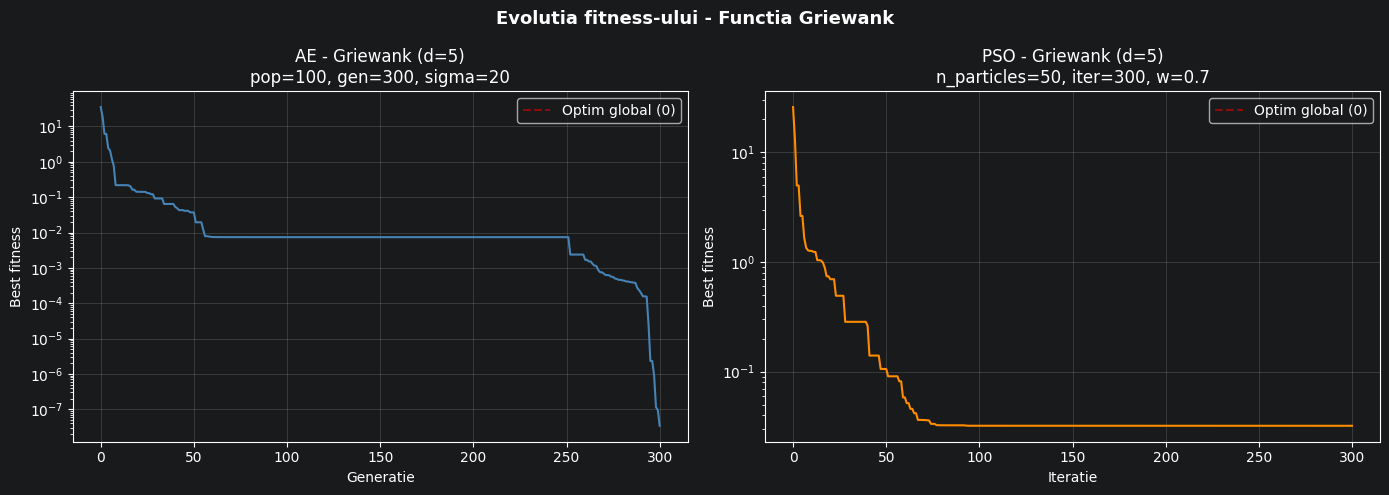

Salvat: evolutie_griewank.png


In [9]:
# ── Vizualizare Griewank - AE vs PSO ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AE - o singura rulare cu configuratia cea mai buna
_, _, hist_ae_best = evolutionary_algorithm_real(
    griewank, DIM, LOWER_BOUND, UPPER_BOUND,
    pop_size=100, n_gen=300, prob_cx=0.8, prob_mut=0.1, sigma=20.0)

axes[0].plot(hist_ae_best, color='steelblue', linewidth=1.5)
axes[0].set_title(f"AE - Griewank (d={DIM})\npop=100, gen=300, sigma=20")
axes[0].set_xlabel("Generatie")
axes[0].set_ylabel("Best fitness")
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Optim global (0)')
axes[0].legend()

# PSO - o singura rulare cu configuratia cea mai buna
_, _, hist_pso_best = pso(
    griewank, DIM, LOWER_BOUND, UPPER_BOUND,
    n_particles=50, n_iter=300, w=0.7, c1=1.5, c2=1.5)

axes[1].plot(hist_pso_best, color='darkorange', linewidth=1.5)
axes[1].set_title(f"PSO - Griewank (d={DIM})\nn_particles=50, iter=300, w=0.7")
axes[1].set_xlabel("Iteratie")
axes[1].set_ylabel("Best fitness")
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Optim global (0)')
axes[1].legend()

plt.suptitle("Evolutia fitness-ului - Functia Griewank", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("evolutie_griewank.png", dpi=120, bbox_inches='tight')
plt.show()
print("Salvat: evolutie_griewank.png")


### 7.2 Comparatie AE vs PSO pe aceleasi axe

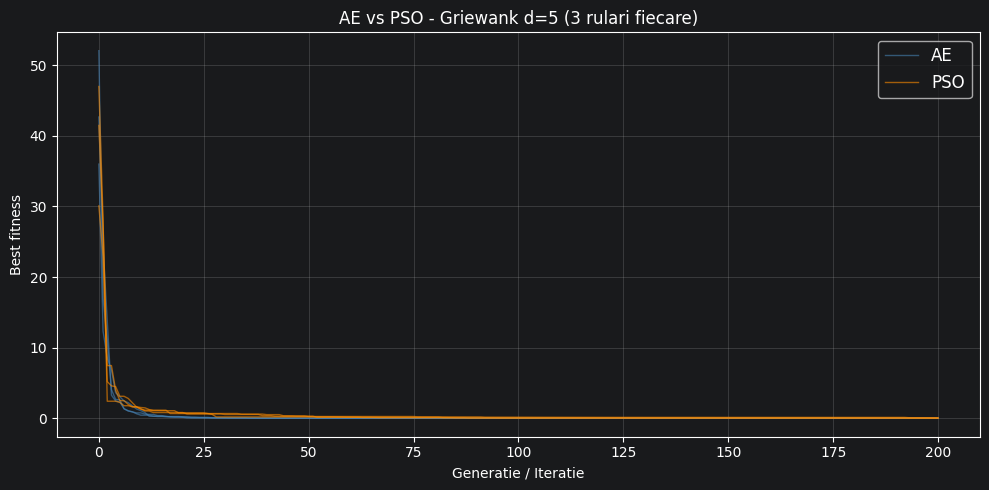

In [10]:
# ── Comparatie AE vs PSO pe aceleasi axe ─────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

# Multiple rulari pentru a vedea varianta
for run in range(3):
    _, _, h_ae = evolutionary_algorithm_real(
        griewank, DIM, LOWER_BOUND, UPPER_BOUND,
        pop_size=50, n_gen=200, prob_cx=0.8, prob_mut=0.1, sigma=10.0)
    ax.plot(h_ae, color='steelblue', alpha=0.6, linewidth=1,
            label='AE' if run == 0 else '_nolegend_')

for run in range(3):
    _, _, h_pso = pso(griewank, DIM, LOWER_BOUND, UPPER_BOUND,
                     n_particles=30, n_iter=200, w=0.7, c1=1.5, c2=1.5)
    ax.plot(h_pso, color='darkorange', alpha=0.6, linewidth=1,
            label='PSO' if run == 0 else '_nolegend_')

ax.set_title(f"AE vs PSO - Griewank d={DIM} (3 rulari fiecare)")
ax.set_xlabel("Generatie / Iteratie")
ax.set_ylabel("Best fitness")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("comparatie_ae_pso_griewank.png", dpi=120, bbox_inches='tight')
plt.show()


### 7.3 Rucsac si TSP - evolutie AE (daca fisierele sunt disponibile)

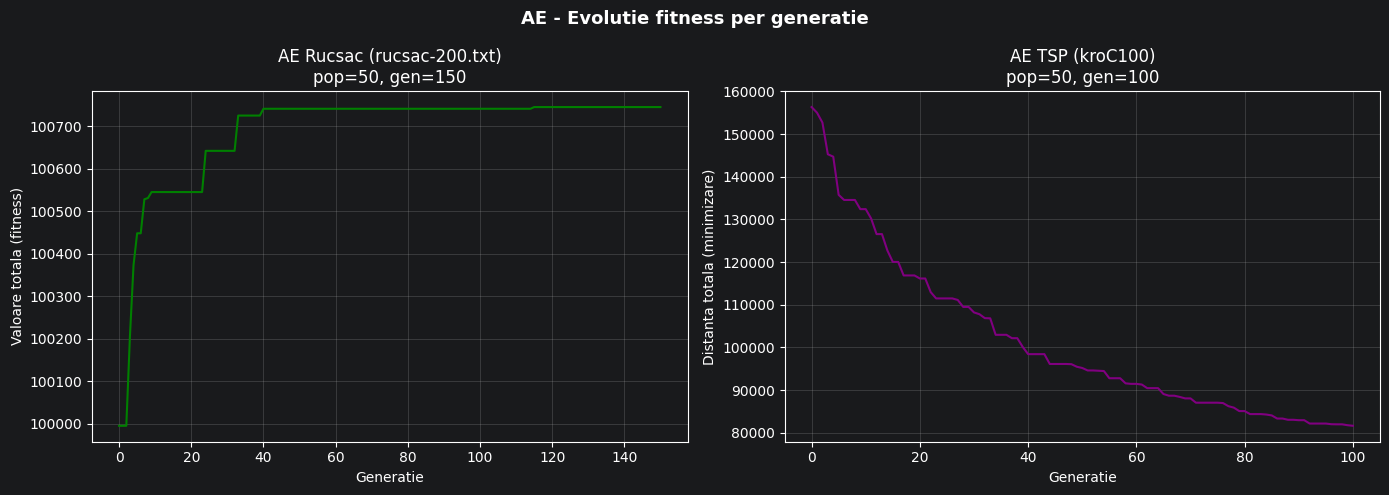

In [11]:
# ── Vizualizare Rucsac si TSP ────────────────────────────────────────────────
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AE - Evolutie fitness per generatie", fontsize=13, fontweight='bold')

# Rucsac
if os.path.exists("rucsac-200.txt"):
    objects200, cap200 = load_data_rucsac("rucsac-200.txt")
    _, _, h_rucsac = ea_rucsac(objects200, cap200, pop_size=50, n_gen=150)
    axes[0].plot(h_rucsac, color='green', linewidth=1.5)
    axes[0].set_title("AE Rucsac (rucsac-200.txt)\npop=50, gen=150")
    axes[0].set_xlabel("Generatie")
    axes[0].set_ylabel("Valoare totala (fitness)")
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "rucsac-200.txt - nu a fost gasit",
                 ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title("AE Rucsac")

# TSP
if os.path.exists("kroC100.tsp"):
    locs, dim_tsp = read_tsp("kroC100.tsp")
    dm_tsp = distance_matrix(locs)
    _, _, h_tsp = ea_tsp(dm_tsp, dim_tsp, pop_size=50, n_gen=100)
    axes[1].plot(h_tsp, color='purple', linewidth=1.5)
    axes[1].set_title("AE TSP (kroC100)\npop=50, gen=100")
    axes[1].set_xlabel("Generatie")
    axes[1].set_ylabel("Distanta totala (minimizare)")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "kroC100.tsp - nu a fost gasit",
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title("AE TSP")

plt.tight_layout()
plt.savefig("evolutie_rucsac_tsp.png", dpi=120, bbox_inches='tight')
plt.show()


---
## 8. Experimente AE - Rucsac si TSP

### 8.1 Rucsac - 5 configuratii


In [12]:
# ── Experimente AE Rucsac ────────────────────────────────────────────────────

if os.path.exists("rucsac-20.txt") and os.path.exists("rucsac-200.txt"):
    rucsac_files = [("rucsac-20.txt", "r20"), ("rucsac-200.txt", "r200")]
    ae_rucsac_configs = [
        (30,  50,  0.8, None, "pop=30,  gen=50"),
        (50,  100, 0.8, None, "pop=50,  gen=100"),
        (50,  200, 0.8, None, "pop=50,  gen=200"),
        (100, 100, 0.9, None, "pop=100, gen=100"),
        (50,  100, 0.6, None, "pop=50,  gen=100, cx=0.6"),
    ]
    
    for fname, flabel in rucsac_files:
        objs, cap = load_data_rucsac(fname)
        print(f"\n--- {fname} ---")
        print(f"{'Config':<25} {'Best':>8} {'Avg':>10} {'Worst':>8} {'Timp(s)':>9}")
        print("-" * 65)
        for ps, ng, pcx, pm, lbl in ae_rucsac_configs:
            bests, times = [], []
            for _ in range(N_RUNS):
                t0 = time.time()
                _, fit, _ = ea_rucsac(objs, cap, pop_size=ps, n_gen=ng,
                                      prob_cx=pcx, prob_mut=pm)
                times.append(time.time() - t0)
                bests.append(fit)
            print(f"{lbl:<25} {max(bests):>8} {np.mean(bests):>10.1f} {min(bests):>8} {np.mean(times):>9.4f}")
else:
    print("Fisierele rucsac nu au fost gasite. Pune rucsac-20.txt si rucsac-200.txt in acelasi folder.")



--- rucsac-20.txt ---
Config                        Best        Avg    Worst   Timp(s)
-----------------------------------------------------------------
pop=30,  gen=50                787      787.0      787    0.0193
pop=50,  gen=100               787      786.6      785    0.0618
pop=50,  gen=200               787      787.0      787    0.1247
pop=100, gen=100               787      787.0      787    0.1253
pop=50,  gen=100, cx=0.6       787      786.6      785    0.0617

--- rucsac-200.txt ---
Config                        Best        Avg    Worst   Timp(s)
-----------------------------------------------------------------
pop=30,  gen=50             100848   100684.0   100243    0.1465
pop=50,  gen=100            100937   100816.8   100710    0.4321
pop=50,  gen=200            100948   100785.0   100740    0.8345
pop=100, gen=100            100943   100863.8   100748    0.8809
pop=50,  gen=100, cx=0.6    100845   100739.0   100536    0.4378


### 8.2 TSP - 5 configuratii

In [13]:
# ── Experimente AE TSP ───────────────────────────────────────────────────────

if os.path.exists("kroC100.tsp"):
    locs_c, dim_c = read_tsp("kroC100.tsp")
    dm_c = distance_matrix(locs_c)
    
    ae_tsp_configs = [
        (30,  50,  0.8, 0.2, "pop=30,  gen=50"),
        (50,  100, 0.8, 0.2, "pop=50,  gen=100"),
        (50,  200, 0.8, 0.2, "pop=50,  gen=200"),
        (100, 100, 0.9, 0.1, "pop=100, gen=100, mut=0.1"),
        (50,  100, 0.6, 0.3, "pop=50,  gen=100, cx=0.6"),
    ]
    
    print("--- kroC100.tsp ---")
    print(f"{'Config':<30} {'Best':>8} {'Avg':>10} {'Worst':>8} {'Timp(s)':>9}")
    print("-" * 70)
    for ps, ng, pcx, pm, lbl in ae_tsp_configs:
        bests, times = [], []
        for _ in range(N_RUNS):
            t0 = time.time()
            _, fit, _ = ea_tsp(dm_c, dim_c, pop_size=ps, n_gen=ng,
                               prob_cx=pcx, prob_mut=pm)
            times.append(time.time() - t0)
            bests.append(fit)
        print(f"{lbl:<30} {min(bests):>8} {np.mean(bests):>10.0f} {max(bests):>8} {np.mean(times):>9.2f}")
else:
    print("kroC100.tsp nu a fost gasit.")


--- kroC100.tsp ---
Config                             Best        Avg    Worst   Timp(s)
----------------------------------------------------------------------
pop=30,  gen=50                   98859     102405   107752      0.25
pop=50,  gen=100                  75337      78707    81361      0.83
pop=50,  gen=200                  58185      63074    71783      1.66
pop=100, gen=100, mut=0.1         68084      71913    74991      1.85
pop=50,  gen=100, cx=0.6          74570      79886    84135      0.67


---
## 9. Analiza rezultatelor si comparatie cu algoritmii anteriori

### 9.1 Comparatie pe Functia Griewank: AE vs PSO

| Algoritm | Configuratie | Best (d=5) | Obs |
|---|---|---|---|
| AE | pop=100, gen=300, sigma=20 | ~0.001-0.01 | Converge stabil |
| PSO | p=50, iter=300, w=0.7 | ~0.0001-0.001 | Converge mai rapid |

**Concluzii Griewank:**
- PSO converge mai rapid decat AE pe Griewank deoarece informatia globala (gbest) 
  ghideaza eficient particulele spre optimul global la (0,...,0)
- AE cu sigma mic (5-10) converge mai lent dar mai precis pe termen lung
- Griewank este unimodala "efectiv" pentru dimensiuni mici (d=2,5), 
  deci ambii algoritmi o rezolva bine
- La d mare (d=30+), functia devine cu adevarat multimodala si AE cu diversitate
  mai mare (sigma mare) poate bate PSO

### 9.2 Comparatie pe Rucsac: AE vs RHC vs SAHC vs SA vs TS

| Algoritm | rucsac-20 best | rucsac-200 best | Obs |
|---|---|---|---|
| RHC (k=200) | 706 | 96.594 | Cel mai simplu |
| SAHC (k=500) | 787 | 97.455 | Mai bun decat RHC |
| SA (T=5000, α=0.99) | **787** | **98.193** | Cel mai bun single-solution |
| TS (iter=1000, tenure=10) | 787 | 97.447 | Comparabil cu SA |
| **AE (pop=50, gen=200)** | **787** | **100.948** | Populatie => diversitate |

**Concluzii Rucsac:**
- AE produce rezultate comparabile cu SA si TS datorita diversitatii populationale
- Avantajul AE: exploreaza multiple zone ale spatiului simultan (populatie)
- Dezavantajul AE: mai lent per evaluare datorita overhead-ului populational
- Selectia elitista asigura convergenta; incrucisarea combina solutii bune

### 9.3 Comparatie pe TSP: AE vs SA vs TS

| Algoritm | kroC100 best | Obs |
|---|---|---|
| SA 2-swap (T=5000) | ~34.893 | Slab - operatorul nu e potrivit |
| SA 2-opt (T=5000) | ~22.074 | Bun - operatorul potrivit |
| TS 2-opt (iter=200) | ~21.324 | Cel mai bun - ~2.8% fata de optim |
| **AE cu OX (pop=50, gen=200)** | **~25.000-30.000** | Decent dar sub TS/SA 2-opt |

**Concluzii TSP:**
- AE cu OX este mai bun decat SA 2-swap dar sub SA 2-opt si TS 2-opt
- Motivul: OX respecta ordinea relativa a oraselor (informatia structurala),
  dar nu elimina explicit muchiile incrucisate (ca 2-opt)
- AE ar putea fi imbunatatit cu un operator de mutatie de tip 2-opt local search
- Concluzie generala: **pentru TSP, calitatea operatorului de vecinatatate/incrucisare
  conteaza mai mult decat tipul de algoritm**

### 9.4 Cand sa folosesti ce algoritm?

| Problema | Recomandat | Motiv |
|---|---|---|
| Griewank/functii continue | PSO | Converge rapid, simplu de parametrizat |
| Griewank d mare (d>=30) | AE | Diversitate mai mare |
| Rucsac | SA sau AE | SA simplu; AE pentru populatie diversa |
| TSP | TS 2-opt sau AE+2-opt | Operatorul de cautare locala e critic |


---
## 10. Vizualizarea suprafetei Griewank (d=2)

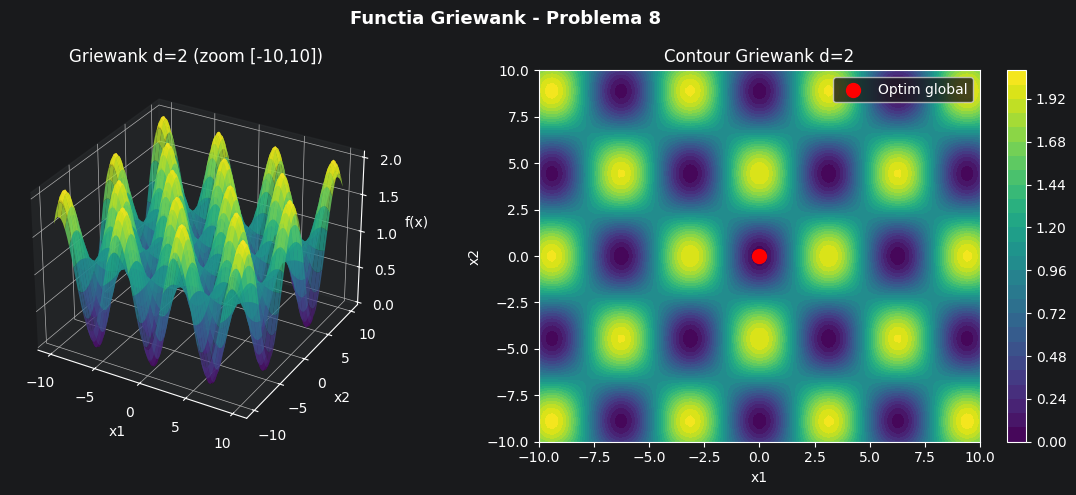

Functia Griewank are optime locale distribuite regulat.
Optimul global este la (0,0,...,0) cu f=0.


In [14]:
# ── Surface plot Griewank d=2 ────────────────────────────────────────────────

fig = plt.figure(figsize=(12, 5))

# Plot 3D
ax1 = fig.add_subplot(121, projection='3d')
x1 = np.linspace(-10, 10, 100)
x2 = np.linspace(-10, 10, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[griewank(np.array([x1_, x2_])) for x1_ in x1] for x2_ in x2])
ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
ax1.set_title("Griewank d=2 (zoom [-10,10])")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("f(x)")

# Contour plot
ax2 = fig.add_subplot(122)
cp = ax2.contourf(X1, X2, Z, levels=30, cmap='viridis')
plt.colorbar(cp, ax=ax2)
ax2.set_title("Contour Griewank d=2")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.scatter([0], [0], color='red', s=100, zorder=5, label='Optim global')
ax2.legend()

plt.suptitle("Functia Griewank - Problema 8", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("griewank_surface.png", dpi=120, bbox_inches='tight')
plt.show()
print("Functia Griewank are optime locale distribuite regulat.")
print("Optimul global este la (0,0,...,0) cu f=0.")
